In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap

sys.path.insert(0, "../../../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
Q = 'Q3'
q = Q.lower()

In [3]:
file1 = f'../../../data/CMacedonia/{NUTS0}_CMacedonia_WNV_Dataset_{Q}_2010_2023.csv'
file2 = f'../../../data/Attica/{NUTS0}_Attica_WNV_Dataset_{Q}_2010_2023.csv'
file3 = f'../../../data/Thessaly/{NUTS0}_Thessaly_WNV_Dataset_{Q}_2010_2023.csv'
file4 = f'../../../data/Thrace/{NUTS0}_Thrace_WNV_Dataset_{Q}_2010_2023.csv'


dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)
dataset4 = read_data(file4)

In [4]:
dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])
dataset.reset_index(drop=True, inplace=True)

In [5]:
dataset

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,4.112363,16.367764,26.181547,33.537056,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,0.504286,-0.299304,0.188064,-0.188064,0.506798,-0.297162,0.191052,-0.191052,0.056979,0.034147,0.053448,0.053448,70168.0,11723.0,44888.0,13557.0,71876.0,11361.0,44491.0,16024.0,2098.630,5025.2,5265.4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,221.404250,49
1,2010,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,4.821270,17.782211,29.032072,28.047625,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,0.348719,-0.178156,0.152549,-0.152549,0.341001,-0.169125,0.153318,-0.153318,0.055008,0.058418,0.057519,0.057519,542053.0,87281.0,374669.0,80103.0,591836.0,83839.0,403005.0,104992.0,21520.330,9804.6,10058.8,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,190.026906,81
2,2010,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,3.783619,17.692167,29.346329,28.019172,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,0.349616,-0.161805,0.179398,-0.179398,0.349630,-0.161106,0.179264,-0.179264,0.045894,0.043199,0.045652,0.045652,39881.0,5916.0,24162.0,9803.0,40875.0,5598.0,23417.0,11860.0,1169.860,5809.2,5920.4,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,2.0,184.019550,23
3,2010,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109782,40.888821,3.685077,16.350589,27.033842,33.702197,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,0.512251,-0.308684,0.182513,-0.182513,0.507571,-0.301060,0.186153,-0.186153,0.052474,0.045819,0.053983,0.053983,70357.0,11214.0,44608.0,14535.0,71745.0,11089.0,43192.0,17464.0,2022.780,5025.2,5265.4,17697.449346,1077.933680,9.795455,157.290051,440.466296,179.112327,0.012547,110.007042,31.0,36.0,30.0,12.0,9.0,4.0,4.0,4.0,2.0,209.445491,57
4,2010,EL52,κεντρικη μακεδονια,EL525,πιερια,22.442423,40.269959,5.759019,17.300494,27.920760,32.606561,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,0.459825,-0.308067,0.140728,-0.140728,0.455635,-0.288171,0.151793,-0.151793,0.062898,0.037329,0.056997,0.056997,61913.0,10377.0,39695.0,11841.0,64447.0,10120.0,40015.0,14312.0,1815.790,5025.2,5265.4,10529.200600,979.257510,11.822222,148.678278,321.171339,171.108861,0.000000,14.790525,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,269.651285,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,2023,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,5.564027,18.216059,3

In [6]:
## Simple output binarization

dataset['WNV_cases'] = dataset['WNV_cases'].apply(lambda x : 1 if(x > 0) else 0)

In [7]:
dataset.columns

Index(['year', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y',
       'min_temp_q3', 'mean_temp_q3', 'max_temp_q3', 'prec_q3', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q3', 'ndwi_q3', 'ndmi_q3', 'ndbi_q3', 'ndvi_mean_q3',
       'ndwi_mean_q3', 'ndmi_mean_q3', 'ndbi_mean_q3', 'ndvi_std_q3',
       'ndwi_std_q3', 'ndmi_std_q3', 'ndbi_std_q3', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1',
       'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'culex_pipiens',
       'WNV_cases'],
      dtype='object')

In [8]:
print(f'Number of NUTS3 Units in dataset: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units in dataset: 22


In [9]:
dsc = dataframe_describe(dataset, target_column = 'WNV_cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,13,9,22,1.44%
1,2011,7,15,22,0.47%
2,2012,10,12,22,0.83%
3,2013,12,10,22,1.20%
4,2014,19,3,22,6.33%
5,2015,22,0,22,inf%
6,2016,22,0,22,inf%
7,2017,22,0,22,inf%
8,2018,4,18,22,0.22%
9,2019,5,17,22,0.29%


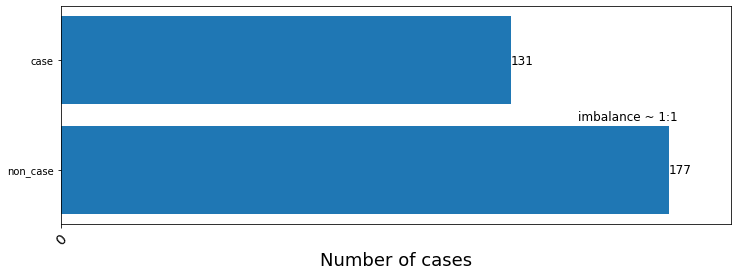

In [10]:
plot_imbalance(dataset, target_column='WNV_cases')

In [11]:
majority_class = 0
near_u = 0
smote = 0.25
scaler = 'minmax'
weight_multiplier = 1

years_to_remove = []

features_to_remove = ['x', 'y', 'year', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1',
       'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw',]

# geo_vars
# features_to_remove = ['x', 'y', 'year', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5','lw', 'qc',]

#features_to_remove=[]
#years_to_remove = []

In [12]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'] 
                                                               + features_to_remove).columns

print(feature_names)

Index(['min_temp_q3', 'mean_temp_q3', 'max_temp_q3', 'prec_q3', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q3', 'ndwi_q3', 'ndmi_q3', 'ndbi_q3', 'ndvi_mean_q3',
       'ndwi_mean_q3', 'ndmi_mean_q3', 'ndbi_mean_q3', 'ndvi_std_q3',
       'ndwi_std_q3', 'ndmi_std_q3', 'ndbi_std_q3', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'culex_pipiens'],
      dtype='object')


In [13]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
x = dataset.drop(columns = ['WNV_cases'])
y = dataset['WNV_cases']
fold = 0
  
for train_idx, test_idx in skf.split(x, y):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    if len(years_to_remove) > 0:
        data_train = data_train.loc[~data_train['year'].isin(years_to_remove)]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, 'WNV_cases', scaler, majority_class, features_to_remove)

    w0,w1 = calculate_weights_new(y_train, weight_multiplier)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test, day_col = None, month_col = None, spatial_col = 'NUTS3_NAME')

    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)
    
    print(f"Fold: {fold} || w0:{w0}, w1:{w1} || ##")
    fold = fold + 1

shap_values= np.concatenate(model_shaps, axis=0)

Fold: 0 || w0:1, w1:1 || ##
Fold: 1 || w0:1, w1:1 || ##
Fold: 2 || w0:1, w1:1 || ##
Fold: 3 || w0:1, w1:1 || ##
Fold: 4 || w0:1, w1:1 || ##
Fold: 5 || w0:1, w1:1 || ##
Fold: 6 || w0:1, w1:1 || ##
Fold: 7 || w0:1, w1:1 || ##
Fold: 8 || w0:1, w1:1 || ##
Fold: 9 || w0:1, w1:1 || ##


In [14]:
feature_names

Index(['min_temp_q3', 'mean_temp_q3', 'max_temp_q3', 'prec_q3', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q3', 'ndwi_q3', 'ndmi_q3', 'ndbi_q3', 'ndvi_mean_q3',
       'ndwi_mean_q3', 'ndmi_mean_q3', 'ndbi_mean_q3', 'ndvi_std_q3',
       'ndwi_std_q3', 'ndmi_std_q3', 'ndbi_std_q3', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'culex_pipiens'],
      dtype='object')

In [15]:
len(feature_names)

55

In [16]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
climate = [f'min_temp_{q}', f'mean_temp_{q}', f'max_temp_{q}', f'prec_{q}']
enviromental = [f'ndvi_{q}',f'ndwi_{q}',f'ndmi_{q}',f'ndbi_{q}',f'ndvi_mean_{q}',f'ndwi_mean_{q}',f'ndmi_mean_{q}',f'ndbi_mean_{q}',f'ndvi_std_{q}',f'ndwi_std_{q}',f'ndmi_std_{q}',f'ndbi_std_{q}']
demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']
vectors = ['culex_pipiens']
trade = ['L_TOTAL',	'UNL_TOTAL']
economic = ['MIO_EUR']

In [17]:
len(bioclimatic+climate+enviromental+demographic+vectors+trade+economic)

47

In [18]:
# coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

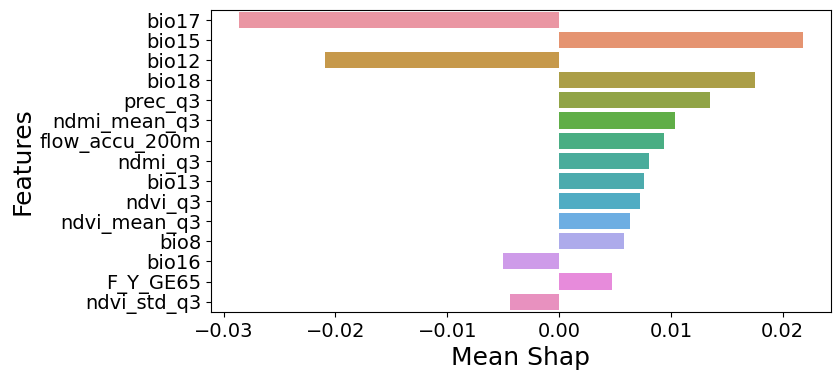

In [19]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

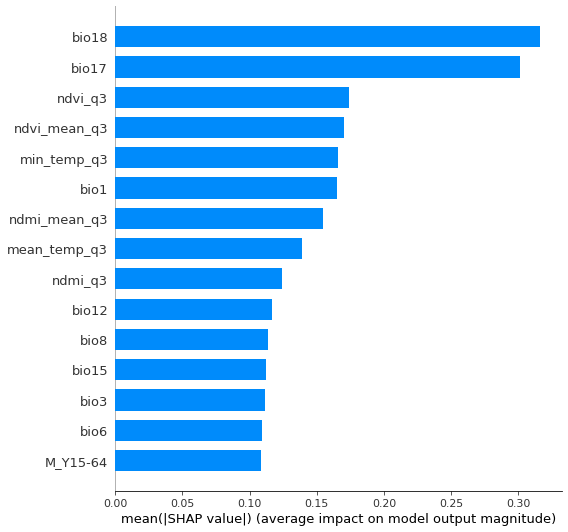

In [20]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

,features,weights
0,bioclimatic,0.130574
2,enviromental,0.039773
3,demographic,0.021927
1,climate,0.019958
5,trade,0.006213
6,economic,0.003143
4,vectors,0.000318


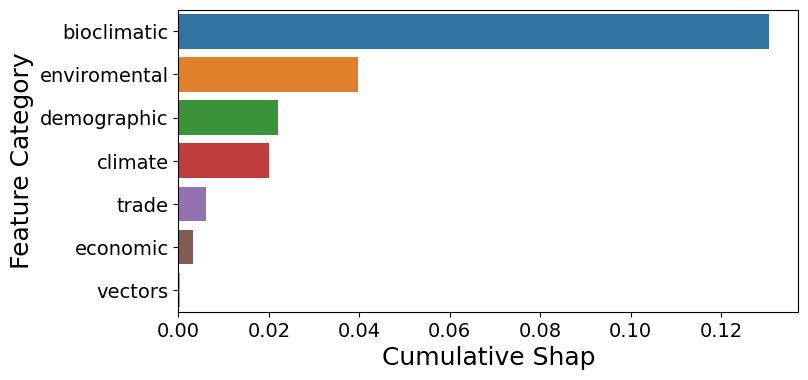

In [21]:
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.weights_abs.sum(),df_climate.weights_abs.sum(),df_enviromental.weights_abs.sum(),
                            df_demographic.weights_abs.sum(),df_vectors.weights_abs.sum(),df_trade.weights_abs.sum(),df_economic.weights_abs.sum()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Cumulative Shap', figure_size = (8, 4))

,features,weights
0,bioclimatic,0.006872
1,climate,0.004990
2,enviromental,0.003314
6,economic,0.003143
5,trade,0.003107
3,demographic,0.002741
4,vectors,0.000318


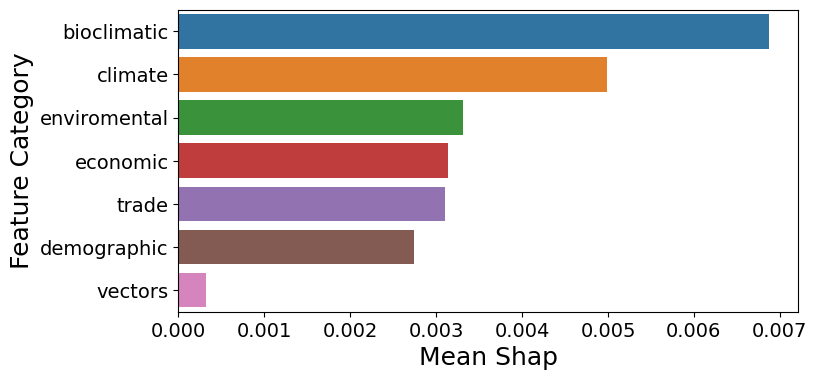

In [22]:
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.weights_abs.mean(),df_climate.weights_abs.mean(),df_enviromental.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_vectors.weights_abs.mean(),df_trade.weights_abs.mean(),df_economic.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

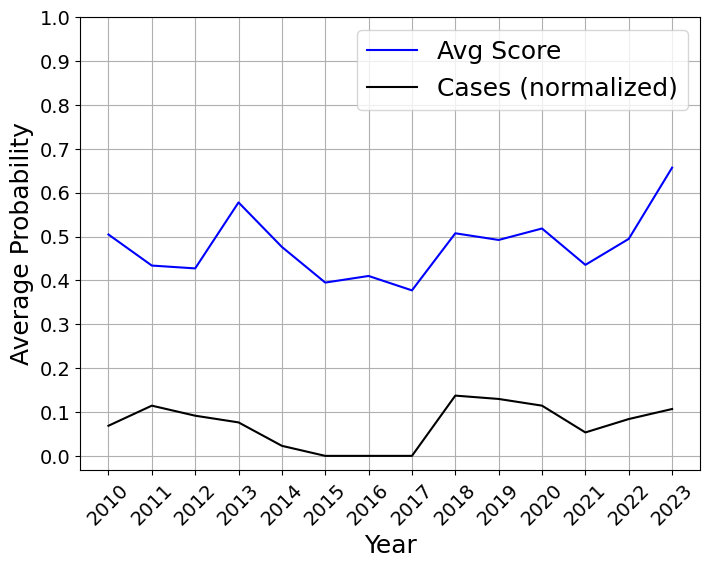

In [23]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case'].iloc[:-1]))

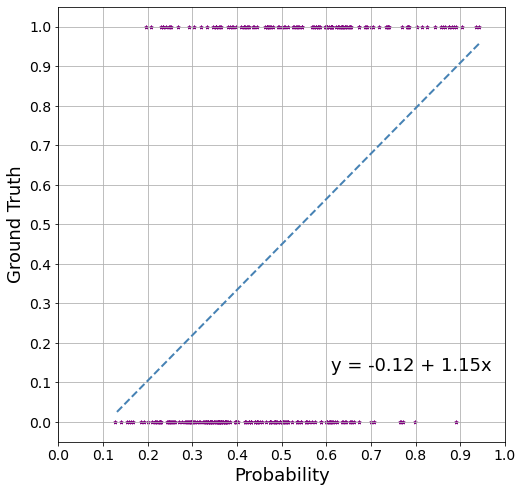

(-0.12493503367526675, 1.1483133321986785)

In [24]:
plot_probability_curve(results_test, marker_size=12)

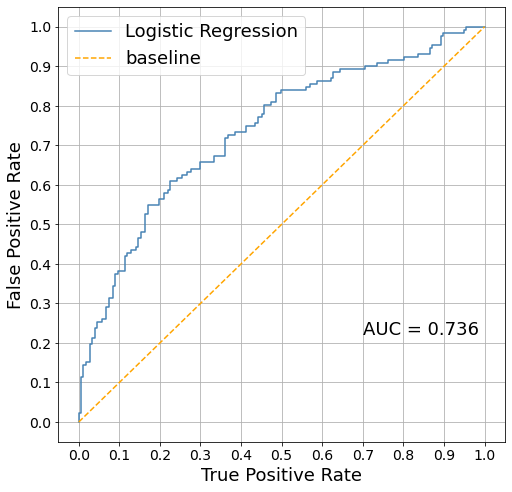

(0.226, 0.6107, 0.526, 0.6875)

In [25]:
plot_roc_curve(results_test)

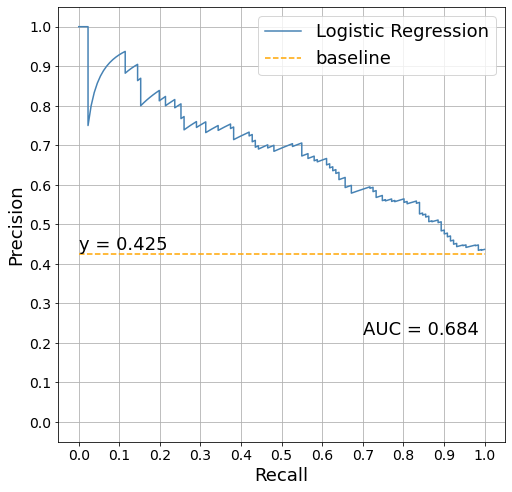

(1.0, 0.44, 0.2, 0.7949)

In [26]:
plot_pr_curve(results_test)

In [27]:
results_train

,case,score
0,1,0.936770
1,1,0.906295
2,1,0.904124
3,1,0.897177
4,1,0.894331
...,...,...
3067,0,0.177411
3068,0,0.175293
3069,0,0.157984
3070,0,0.147448


In [28]:
logloss_train = log_loss(results_train.case, results_train.score, labels = [0,1])
logloss_train

0.5434467073328267

In [29]:
results_test

,NUTS3_NAME,year,case,score
0,δραμα,2023,1,0.941838
1,θεσσαλονικη,2023,1,0.935547
2,θεσσαλονικη,2010,1,0.903593
3,θεσσαλονικη,2014,0,0.891556
4,ημαθια,2023,1,0.891501
...,...,...,...,...
303,δυτικος τομεας αθηνων,2019,0,0.161876
304,δυτικος τομεας αθηνων,2021,0,0.158571
305,δυτικη αττικη,2021,0,0.153831
306,"πειραιας, νησοι",2020,0,0.139473


In [30]:
results_test['pred_01'] = results_test['score'].apply(lambda x: 1 if x>= 0.1 else 0)
results_test['pred_02'] = results_test['score'].apply(lambda x: 1 if x>= 0.2 else 0)
results_test['pred_05'] = results_test['score'].apply(lambda x: 1 if x>= 0.5 else 0)

In [31]:
results_test

,NUTS3_NAME,year,case,score,pred_01,pred_02,pred_05
0,δραμα,2023,1,0.941838,1,1,1
1,θεσσαλονικη,2023,1,0.935547,1,1,1
2,θεσσαλονικη,2010,1,0.903593,1,1,1
3,θεσσαλονικη,2014,0,0.891556,1,1,1
4,ημαθια,2023,1,0.891501,1,1,1
...,...,...,...,...,...,...,...
303,δυτικος τομεας αθηνων,2019,0,0.161876,1,0,0
304,δυτικος τομεας αθηνων,2021,0,0.158571,1,0,0
305,δυτικη αττικη,2021,0,0.153831,1,0,0
306,"πειραιας, νησοι",2020,0,0.139473,1,0,0


In [32]:
accuracy_01 = accuracy_score(results_test.case, results_test.pred_01)
balanced_accuracy_01 = balanced_accuracy_score(results_test.case, results_test.pred_01)
fb_score_01 = fbeta_score(results_test.case, results_test.pred_01, beta = 1, labels = [0,1], zero_division = 0)
precision_01 = precision_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
recall_01 = recall_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
logloss_01 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [33]:
accuracy_02 = accuracy_score(results_test.case, results_test.pred_02)
balanced_accuracy_02 = balanced_accuracy_score(results_test.case, results_test.pred_02)
fb_score_02 = fbeta_score(results_test.case, results_test.pred_02, beta = 1, labels = [0,1], zero_division = 0)
precision_02 = precision_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
recall_02 = recall_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
logloss_02 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [34]:
accuracy_05 = accuracy_score(results_test.case, results_test.pred_05)
balanced_accuracy_05 = balanced_accuracy_score(results_test.case, results_test.pred_05)
fb_score_05 = fbeta_score(results_test.case, results_test.pred_05, beta = 1, labels = [0,1], zero_division = 0)
precision_05 = precision_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
recall_05 = recall_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
logloss_05 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [35]:
thr_01 = {'accuracy': accuracy_01, 'balanced_accuracy': balanced_accuracy_01, 
          'f1_score': fb_score_01, 'precision': precision_01, 'recall': recall_01, 'logloss': logloss_01}

thr_02 = {'accuracy': accuracy_02, 'balanced_accuracy': balanced_accuracy_02, 
          'f1_score': fb_score_02, 'precision': precision_02, 'recall': recall_02, 'logloss': logloss_02}

thr_05 = {'accuracy': accuracy_05, 'balanced_accuracy': balanced_accuracy_05, 
          'f1_score': fb_score_05, 'precision': precision_05, 'recall': recall_05, 'logloss': logloss_05}

In [36]:
results_df = pd.DataFrame([thr_01, thr_02, thr_05])
results_df.index = ['Threshold: 0.1', 'Threshold: 0.2', 'Threshold: 0.5']

In [37]:
results_df

,accuracy,balanced_accuracy,f1_score,precision,recall,logloss
Threshold: 0.1,0.425325,0.500000,0.596811,0.425325,1.000000,0.600041
Threshold: 0.2,0.448052,0.518782,0.604651,0.434783,0.992366,0.600041
Threshold: 0.5,0.685065,0.679368,0.633962,0.626866,0.641221,0.600041
